# GTSummary

##### How to install a package 

```R
install.packages("gtsummary")
```

In [2]:
library(gtsummary)
library(tidyverse)

── Attaching core tidyverse packages ───────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ─────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


In [3]:
# import data
nhanes <- read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ─────────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome, Hom...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Length, He...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
#number of observations (rows)
nhanes |> nrow()

[1] 20293

In [6]:
#number of variables (columns)
nhanes |> ncol()

[1] 78

In [7]:
#variable names
nhanes |> names()

 [1] "ID"               "SurveyYr"         "Gender"           "Age"             
 [5] "AgeMonths"        "Race1"            "Race3"            "Education"       
 [9] "MaritalStatus"    "HHIncome"         "HHIncomeMid"      "Poverty"         
[13] "HomeRooms"        "HomeOwn"          "Work"             "Weight"          
[17] "Length"           "HeadCirc"         "Height"           "BMI"             
[21] "BMICatUnder20yrs" "BMI_WHO"          "Pulse"            "BPSysAve"        
[25] "BPDiaAve"         "BPSys1"           "BPDia1"           "BPSys2"          
[29] "BPDia2"           "BPSys3"           "BPDia3"           "Testosterone"    
[33] "DirectChol"       "TotChol"          "UrineVol1"        "UrineFlow1"      
[37] "UrineVol2"        "UrineFlow2"       "Diabetes"         "DiabetesAge"     
[41] "HealthGen"        "DaysPhysHlthBad"  "DaysMentHlthBad"  "LittleInterest"  
[45] "Depressed"        "nPregnancies"     "nBabies"          "Age1stBaby"      
[49] "SleepHrsNight"    "Sle

In [8]:
#variable types
nhanes |> glimpse()

Rows: 20,293
Columns: 78
$ ID               <dbl> 51624, 51625, 51626, 51627, 51628, 51629, 51630, 51631, 51…
$ SurveyYr         <chr> "2009_10", "2009_10", "2009_10", "2009_10", "2009_10", "20…
$ Gender           <chr> "male", "male", "male", "male", "female", "male", "female"…
$ Age              <dbl> 34, 4, 16, 10, 60, 26, 49, 1, 10, 80, 10, 80, 4, 35, 9, 4,…
$ AgeMonths        <dbl> 409, 49, 202, 131, 722, 313, 596, 12, 124, NA, 121, NA, 48…
$ Race1            <chr> "White", "Other", "Black", "Black", "Black", "Mexican", "W…
$ Race3            <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ Education        <chr> "High School", NA, NA, NA, "High School", "9 - 11th Grade"…
$ MaritalStatus    <chr> "Married", NA, NA, NA, "Widowed", "Married", "LivePartner"…
$ HHIncome         <chr> "25000-34999", "20000-24999", "45000-54999", "20000-24999"…
$ HHIncomeMid      <dbl> 30000, 22500, 50000, 22500, 12500, 30000, 40000, 40000, 70…
$ Poverty          <dbl> 1.36, 1.07, 2.2

Warning message:
Removed 5426 rows containing non-finite outside the scale range (`stat_bin()`). 


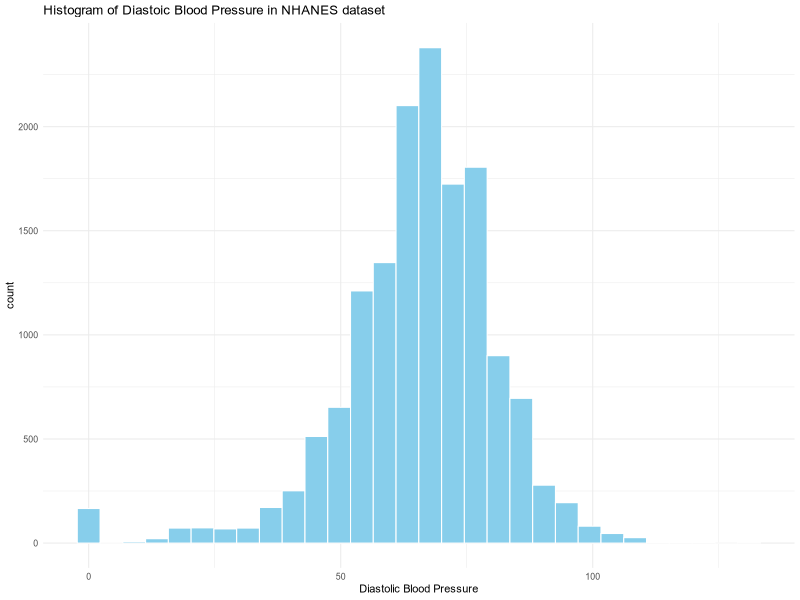

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.

In [22]:
#univariate analysis
#numeric 
# distribution

nhanes |> 
  ggplot() +  
  aes(x=BPDiaAve) + 
  geom_histogram(color='white', fill='skyblue') + 
  theme_minimal() + 
  xlab("Diastolic Blood Pressure") + 
  labs(title="Histogram of Diastoic Blood Pressure in NHANES dataset")

In [11]:
nhanes |> with(BPDiaAve) |> summary()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
    0.0    58.0    67.0    65.6    75.0   131.0    5426 

In [15]:
nhanes |> with(BPDiaAve) |> sd(na.rm=T)

[1] 15.62917

In [ ]:
#Using summarise
nhanes |> summarise(
  Mean=mean(BPDiaAve, na.rm=T ), 
  StandardDeviation = sd(BPDiaAve, na.rm=T)
)

# A tibble: 1 × 2
   Mean StandardDeviation
  <dbl>             <dbl>
1  65.6              15.6

Warning message:
Removed 5426 rows containing non-finite outside the scale range (`stat_boxplot()`). 


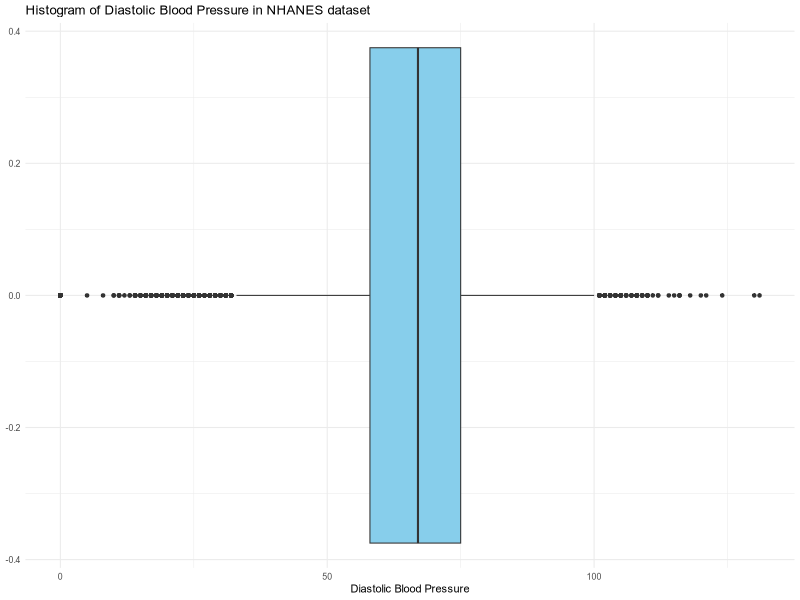

In [24]:
nhanes |> ggplot() + 
  aes(x=BPDiaAve) + 
  geom_boxplot(fill='skyblue') + 
  theme_minimal() + 
  xlab("Diastolic Blood Pressure") + 
  labs(title="Histogram of Diastolic Blood Pressure in NHANES dataset")

In [ ]:
#race 

nhanes |> with(Race1) |> table() 


   Black Hispanic  Mexican    Other    White 
    4640     2209     3739     2312     7393 

In [26]:
nhanes |> with(Race1) |> table() |> prop.table()


    Black  Hispanic   Mexican     Other     White 
0.2286503 0.1088553 0.1842507 0.1139309 0.3643128 

In [27]:
nhanes |> with(Race1) |> table() |> prop.table() * 100


   Black Hispanic  Mexican    Other    White 
22.86503 10.88553 18.42507 11.39309 36.43128 

In [ ]:
#Using summarise
nhanes |> 
  group_by(Race1) |>
  summarise(
    Frequency = n()
  ) |> 
  mutate(Prop = Frequency/sum(Frequency)) |> 
  mutate(Percent = Prop * 100)

# A tibble: 5 × 4
  Race1    Frequency  Prop Percent
  <chr>        <int> <dbl>   <dbl>
1 Black         4640 0.229    22.9
2 Hispanic      2209 0.109    10.9
3 Mexican       3739 0.184    18.4
4 Other         2312 0.114    11.4
5 White         7393 0.364    36.4

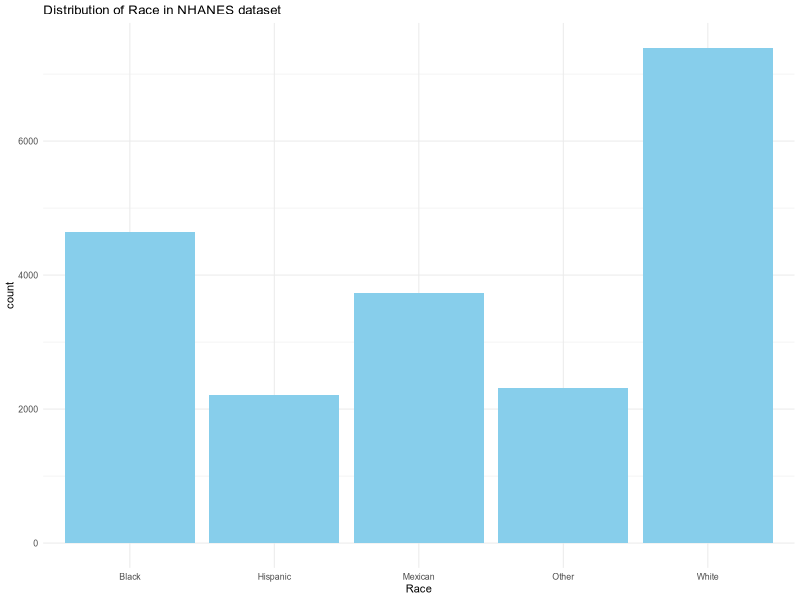

In [40]:
nhanes |> ggplot() + 
  aes(x=Race1) + 
  geom_bar(fill='skyblue') + 
  theme_minimal() + 
  xlab("Race") + 
  labs(title = "Distribution of Race in NHANES dataset")

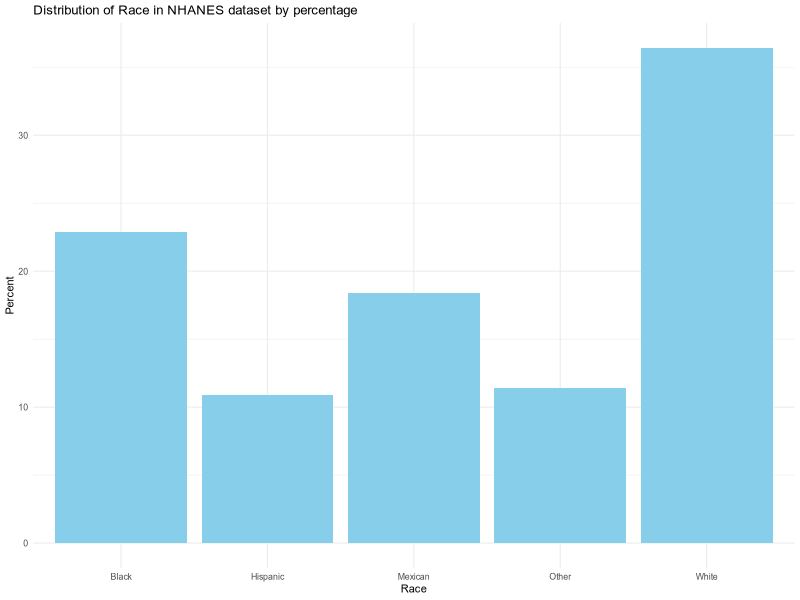

In [52]:
#Using summarise
nhanes |> 
  group_by(Race1) |>
  summarise(
    Frequency = n()
  ) |> 
  mutate(Prop = Frequency/sum(Frequency)) |> 
  mutate(Percent = Prop * 100) |> 
  ggplot() + aes(x=Race1, y=Percent) + geom_col(fill='skyblue') + 
  theme_minimal() + 
  xlab("Race") + 
  labs(title = "Distribution of Race in NHANES dataset by percentage")

In [54]:
nhanes |> 
  tbl_summary(
    include = c(BPDiaAve, Race1)
  )

<R HTML widget HTML Widget>

In [76]:
#Customizing tbl_summary()
nhanes |> 
  tbl_summary(
    include = c(Age, Gender, BPDiaAve, Race1, Education), #selects the variables you want
    missing = 'no',  #removes missing from the final table
    label = list(Gender ~ 'Sex', Race1 ~ 'Race'),  #use label to rename variables
    statistic = list(Age ~ '{mean} (±{sd})'), #change the statistic being displayed
    digits = list(Age ~ c(1, 1), BPDiaAve ~ c(0, 0),  all_categorical() ~ c(0, 1))
  )

<R HTML widget HTML Widget>

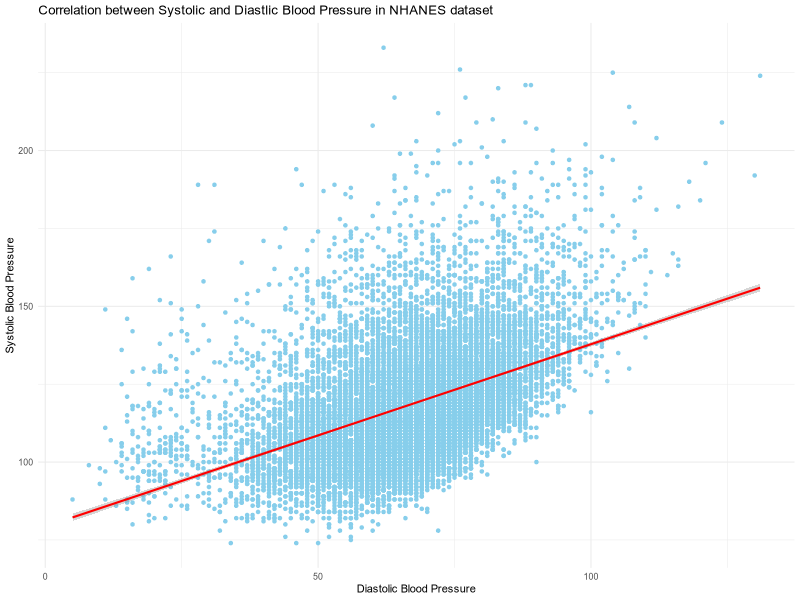

`geom_smooth()` using formula = 'y ~ x'

In [83]:
# Bivariate analysis
# Numeric vs Numeric

nhanes |> 
  filter(BPDiaAve > 0, BPSysAve > 0) |>
  ggplot() + 
  aes(x=BPDiaAve, y=BPSysAve) + 
  geom_point(color='skyblue') + 
  geom_smooth(method=lm, color='red') + 
  xlab("Diastolic Blood Pressure") +
  ylab("Systolic Blood Pressure") + 
  labs(title="Correlation between Systolic and Diastlic Blood Pressure in NHANES dataset") + 
  theme_minimal()

In [84]:
# correlation 
nhanes |>  
  select(BPDiaAve, BPSysAve) |> 
  cor(use='complete.obs')

          BPDiaAve  BPSysAve
BPDiaAve 1.0000000 0.4117715
BPSysAve 0.4117715 1.0000000

In [91]:
# Numeric and categorical 
# Numeric summaries (center and spread) at each level of the categorical variable

nhanes |> 
  group_by(Race1) |> 
  summarise(
    mean=mean(BPSysAve, na.rm=T), 
    stdev=sd(BPSysAve, na.rm=T), 
  )

# A tibble: 5 × 3
  Race1     mean stdev
  <chr>    <dbl> <dbl>
1 Black     121.  19.5
2 Hispanic  116.  18.2
3 Mexican   115.  18.2
4 Other     115.  16.8
5 White     119.  18.1

Warning message:
Removed 5426 rows containing non-finite outside the scale range (`stat_boxplot()`). 


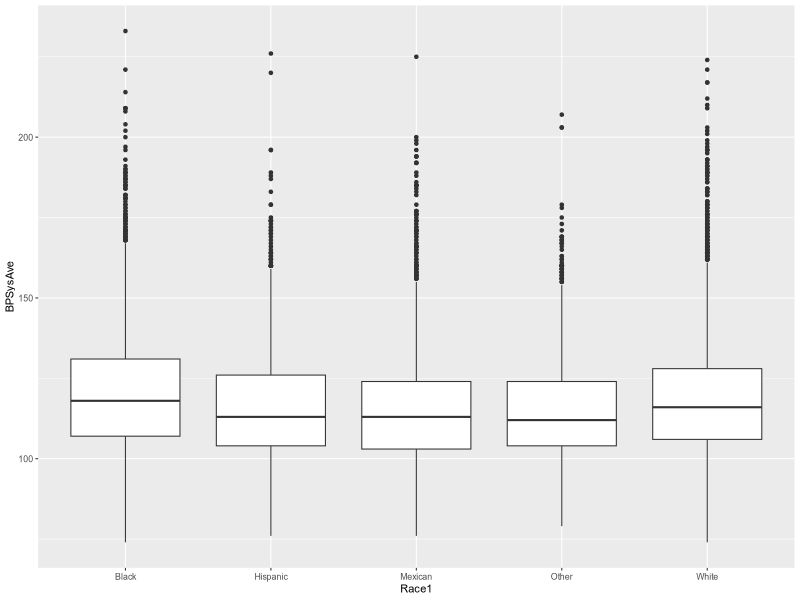

In [92]:
nhanes |> 
  ggplot() + aes(x=Race1, y=BPSysAve) + geom_boxplot()

Warning message:
Removed 5426 rows containing non-finite outside the scale range (`stat_boxplot()`). 


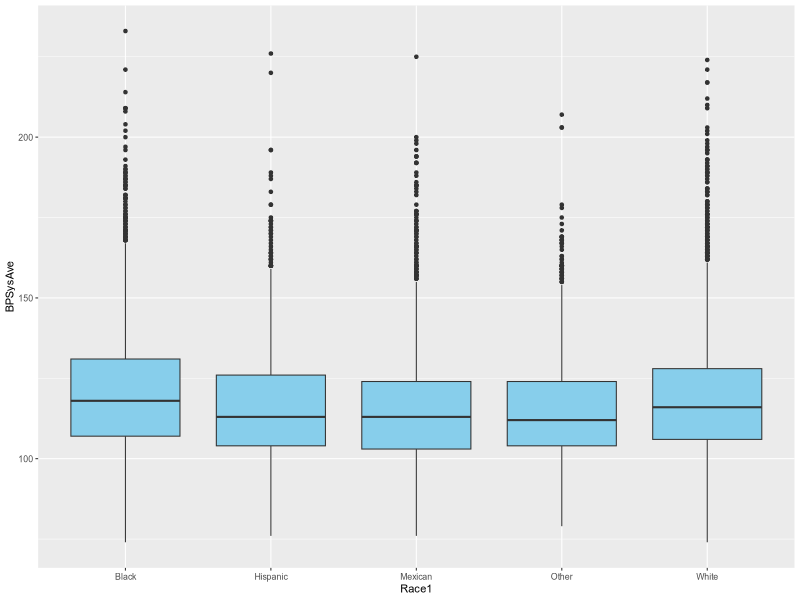

In [93]:
nhanes |> 
  ggplot() + aes(x=Race1, y=BPSysAve) + geom_boxplot(fill='skyblue')

Warning message:
Removed 5426 rows containing non-finite outside the scale range (`stat_boxplot()`). 


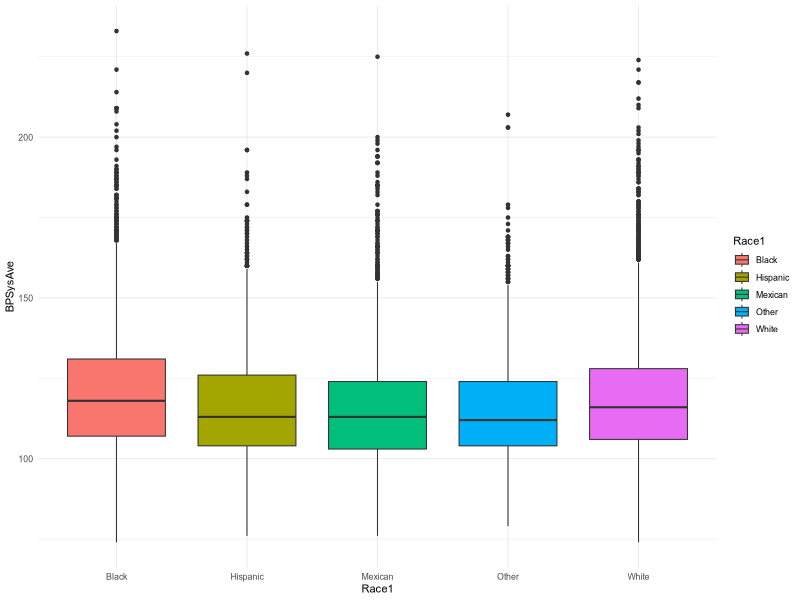

In [95]:
nhanes |> 
  ggplot() + aes(x=Race1, y=BPSysAve, fill=Race1) + geom_boxplot() + theme_minimal()

In [96]:
# Cat vs Cat 
# 2 way table of freq and props
# row prop/percent or column prop/percent

nhanes |>
  select(Gender, Race1) |> 
  table()

        Race1
Gender   Black Hispanic Mexican Other White
  female  2357     1145    1851  1176  3683
  male    2283     1064    1888  1136  3710

In [97]:
nhanes |>
  select(Gender, Race1) |> 
  table() |> prop.table()

        Race1
Gender        Black   Hispanic    Mexican      Other      White
  female 0.11614843 0.05642340 0.09121372 0.05795102 0.18149115
  male   0.11250185 0.05243187 0.09303701 0.05597989 0.18282166

In [98]:
nhanes |>
  select(Gender, Race1) |> 
  table() |> prop.table() * 100

        Race1
Gender       Black  Hispanic   Mexican     Other     White
  female 11.614843  5.642340  9.121372  5.795102 18.149115
  male   11.250185  5.243187  9.303701  5.597989 18.282166

In [ ]:
#Row percentages
nhanes |>
  select(Gender, Race1) |> 
  table() |> prop.table(1) * 100

        Race1
Gender      Black Hispanic  Mexican    Other    White
  female 23.08069 11.21230 18.12573 11.51586 36.06541
  male   22.64656 10.55451 18.72830 11.26872 36.80190

In [ ]:
#Column percentages
nhanes |>
  select(Gender, Race1) |> 
  table() |> prop.table(2) * 100

        Race1
Gender      Black Hispanic  Mexican    Other    White
  female 50.79741 51.83341 49.50522 50.86505 49.81739
  male   49.20259 48.16659 50.49478 49.13495 50.18261

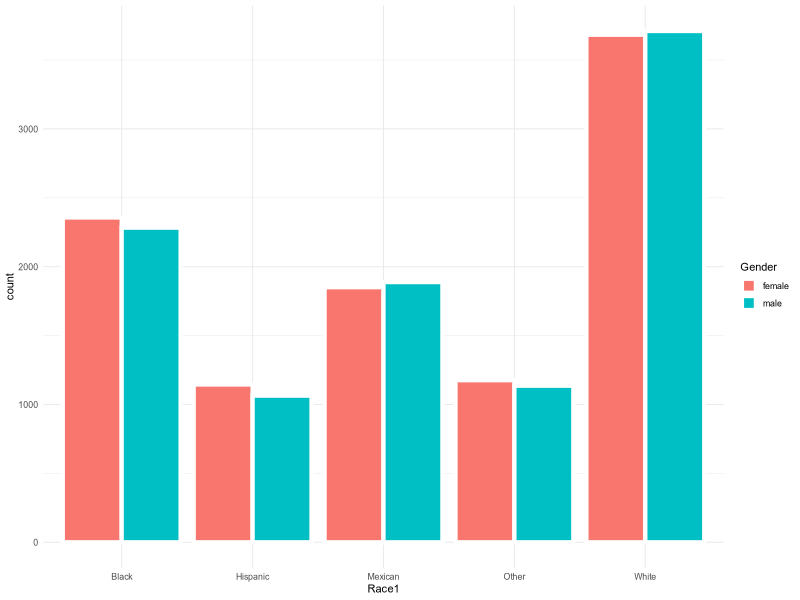

In [110]:
nhanes |> 
  ggplot() + aes(x=Race1, fill=Gender) + geom_bar(position='dodge', color='white', lwd=2) + theme_minimal()

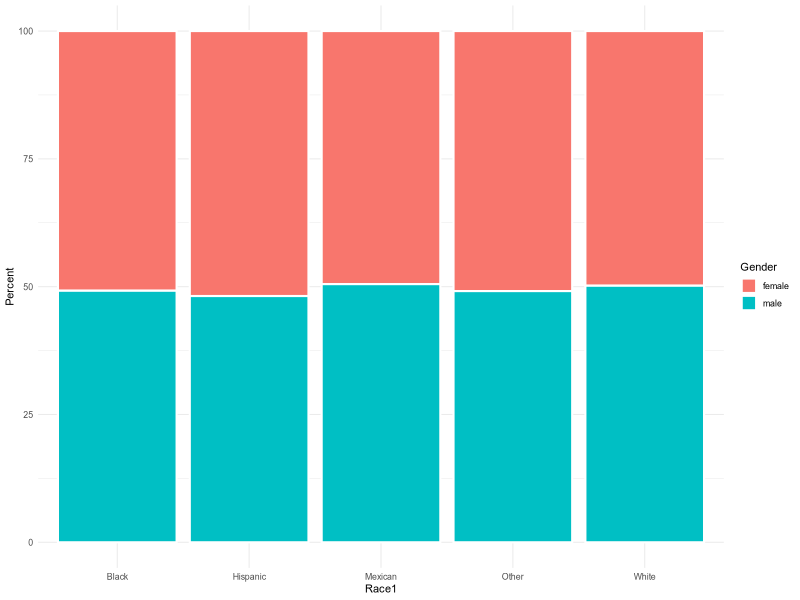

In [ ]:
nhanes |> 
  group_by(Race1, Gender) |> 
  summarise(
    Freq = n(), .groups = 'drop_last'
  ) |> 
  mutate(Prop = Freq/sum(Freq)) |> 
  mutate(Percent = Prop * 100) |> 
  ggplot() + 
  aes(x=Race1, y=Percent, fill=Gender) + 
  geom_col(color='white', lwd=1) + 
  theme_minimal()

In [133]:
nhanes |> 
  tbl_summary(
    include = c(Gender, Age,  BPDiaAve, BPSysAve, Education), 
    by=Race1
  )

<R HTML widget HTML Widget>

In [132]:
nhanes |> 
  tbl_summary(
    include = c(Gender, Age,  BPDiaAve, BPSysAve, Education), 
    by=Race1, 
    missing = 'no',  #removes missing from the final table
    label = list(Gender ~ 'Sex'),  #use label to rename variables
    statistic = list(Age ~ '{mean} (±{sd})'), #change the statistic being displayed
    digits = list(Age ~ c(1, 1), BPDiaAve ~ c(0, 0),  all_categorical() ~ c(0, 1))
  )

<R HTML widget HTML Widget>

In [135]:
nhanes |> 
  tbl_summary(
    include = c(Age, Race1, BPDiaAve, BPSysAve, Education), 
    by=Gender, 
    missing = 'no',  #removes missing from the final table
    statistic = list(Age ~ '{mean} (±{sd})'), #change the statistic being displayed
    digits = list(Age ~ c(1, 1), BPDiaAve ~ c(0, 0),  all_categorical() ~ c(0, 1))
  ) |> add_overall()

<R HTML widget HTML Widget>